# Country Matrix Generator

A Jupyter notebook designed to generate `mapdata/cmat.bin`, which contains an `np.ndarray` with shape `(600, 1440)`. Each entry is an integer representing a country's ID. This binary file is necessary for the main notebook responsible for computing the average, standard deviation, minimum, and maximum daily temperature range of each country.

## Step 1

First, we'll need to import the necessary packages and initialize a helper class.

In [2]:
from utils import CountryFinder
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import math

cf = CountryFinder()
print(cf)

CountryFinder for 250 Countries


## Step 2

After creating a `CountryFinder`, the notebook computes the country ID for each every longitude and latitude combination. If the ID is `-1`, then there is no country at those coordinates.

In [3]:
WORLD_SHAPE = (600, 1440)

data = np.ones(WORLD_SHAPE) * -1
for i in range(WORLD_SHAPE[0]):
    print(f"Generating country matrix... {(i+1) * 100 / WORLD_SHAPE[0]:.2f}%", end='\r')
    lat = i * 180 / WORLD_SHAPE[0] - 90
    for j in range(WORLD_SHAPE[1]):
        lon = j * 360 / WORLD_SHAPE[1]
        cid = cf.findi(lat, lon)
        if cid is not None:
            data[i][j] = cid
print()

data.tofile("mapdata/cmat.bin")

Generating country matrix... 100.00%


## Step 3

Finally, display the country data to prove the file's validity.

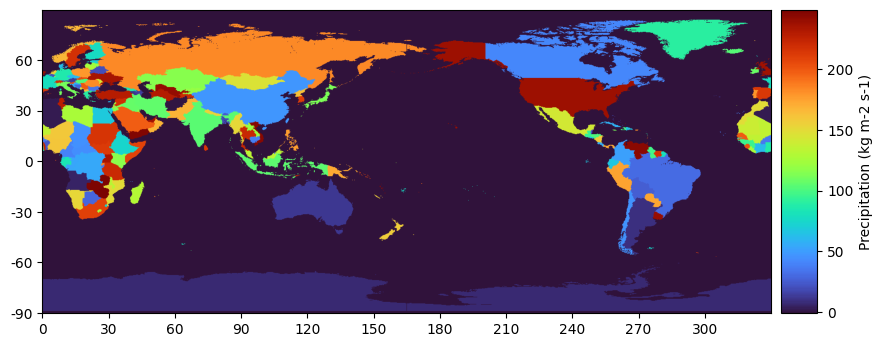

In [4]:
y_max, x_max = data.shape
xlabels = [str(x) for x in range(0, 360, 30)]
ylabels = [str(y) for y in range(-90, 91, 30)]
xticks = np.linspace(0, x_max, len(xlabels))
yticks = np.linspace(0, y_max, len(ylabels))

# Create the plot
fig, axes = plt.subplots(1, 1,figsize=(10, 8))
axes.set_xticks(xticks)
axes.set_xticklabels(xlabels)
axes.set_yticks(yticks)
axes.set_yticklabels(ylabels)

# Plot the data
im = axes.imshow(data[:, :], origin='lower', cmap='turbo')

divider = make_axes_locatable(axes)
cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and pad as needed

# Add the colorbar
cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Precipitation (kg m-2 s-1)')

# Show the plot
plt.show()